### Loading Dataframe

In [179]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('student_exam_scores.csv', header=0)
df.head()

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,S001,8.0,8.8,72.1,45,30.2
1,S002,1.3,8.6,60.7,55,25.0
2,S003,4.0,8.2,73.7,86,35.8
3,S004,3.5,4.8,95.1,66,34.0
4,S005,9.1,6.4,89.8,71,40.3


### Getting general Info

In [180]:
print(pd.DataFrame(df.info()))
print(pd.DataFrame(df.describe()))
print("Df Columns:", list(df.columns))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_id          200 non-null    object 
 1   hours_studied       200 non-null    float64
 2   sleep_hours         200 non-null    float64
 3   attendance_percent  200 non-null    float64
 4   previous_scores     200 non-null    int64  
 5   exam_score          200 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 9.5+ KB
Empty DataFrame
Columns: []
Index: []
       hours_studied  sleep_hours  attendance_percent  previous_scores  \
count     200.000000   200.000000          200.000000       200.000000   
mean        6.325500     6.622000           74.830000        66.800000   
std         3.227317     1.497138           14.249905        15.663869   
min         1.000000     4.000000           50.300000        40.000000   
25%         3.500000     5.300000 

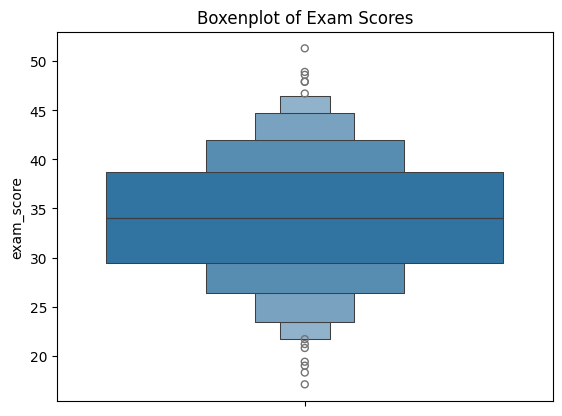

Max Score: 51.3 Min Score: 17.1
Mean Score: 33.955
Median Score: 34.05
Mode: 36.1


In [181]:
sns.boxenplot(data=df["exam_score"])
plt.title("Boxenplot of Exam Scores")
plt.show()
print("Max Score:", df["exam_score"].max(), "Min Score:", df["exam_score"].min())
print("Mean Score:", df["exam_score"].mean())
print("Median Score:", df["exam_score"].median())
print("Mode:", df["exam_score"].mode()[0])


# Correlation Matrix and Heatmap

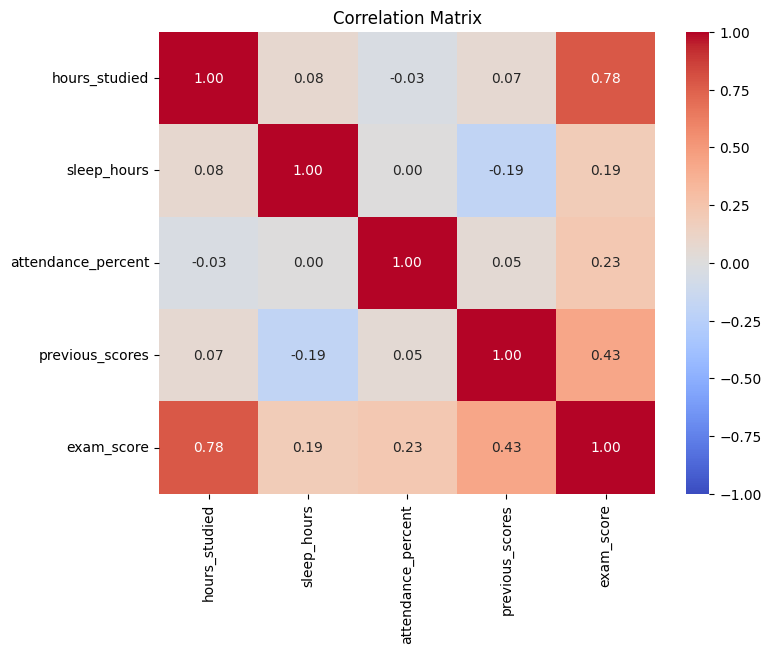

In [182]:
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

From the heatmap we've seen that every feature is useful to explain the final grade; they have not much correlation so i will use them all.

### Splitting Features and Target

I'm not relying on training and evaluation dataset for the simple reason that the dataset is very small so to limit the overfitting  
we're gonna use a regularized model and use crossvalidation as a overfitting evaluator.


In [183]:
features_df = df[['hours_studied', 'sleep_hours', 'attendance_percent','previous_scores']]
target_df = df['exam_score']

### Training the model

I've chosen Ridge to limit overfitting, and since there are not many features all worth of attention

In [184]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Ridge  
from sklearn.metrics import mean_squared_error

pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('ridge_regression', Ridge(alpha=1))
])

ridge_model = pipeline.fit(features_df, target_df)
predictions = pipeline.predict(features_df)
print(ridge_model.score(features_df, target_df))
mse = mean_squared_error(target_df, predictions)
print("Mean Squared Error:", mse)

0.838979464293677
Mean Squared Error: 7.385605395996379


### Cross Validation

I'm working on a small dataset so it has no sense to rely on Training and Evaluation set overfitting check, so our overfitting index will be cross validation

In [185]:
from sklearn.model_selection import KFold, cross_val_score

cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores = cross_val_score(ridge_model, features_df, target_df, cv=cv, scoring="r2")
mse_scores = cross_val_score(ridge_model, features_df, target_df, cv=cv, scoring="neg_mean_squared_error")
print("Average R²:", np.mean(r2_scores))
print("Average MSE:", -np.mean(mse_scores))

Average R²: 0.830717791088078
Average MSE: 7.615499759498476


### Results :

Considered everything we've said i consider my results appropriate and truthful, the model is likely not overfitted and there is no data leakage:

### -----In the end the model is Able to Explain a solid 83% of the final grade-------